<a href="https://colab.research.google.com/github/14003771CR/Text-Mining-Image-Recognition.-Proyecto-Final/blob/main/Problema1_word_cloud_Cyndi_Raxjal_14003771.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cyndi Marjorie Nohemy Raxjal Pirir
14003771

#Text Mining & Image Recognition
##Proyecto Final


---
# Problema 1 — Word Cloud (Text Mining)

In [12]:
# !pip install wordcloud nltk -q


In [13]:
import re
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. Carga del dataset


In [14]:
DATASET_PATH = "tw_source.csv"

cols = ["target", "id", "date", "flag", "user", "text"]
df = pd.read_csv(DATASET_PATH, header=None, names=cols, encoding="latin-1")
df = df.dropna(subset=["text"]).reset_index(drop=True)
df["text"] = df["text"].astype(str)
df = df.rename(columns={"date": "timestamp"})

print("Filas, columnas:", df.shape)
df.head()


Filas, columnas: (1600000, 6)


,target,id,timestamp,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## 2. Determinar los 3 usuarios más citados

Se usó una expresión regular para extraer todas las menciones `@usuario` dentro de cada tweet y se cuenta su frecuencia.

In [15]:
mention_pattern = re.compile(r'@(\w+)')

def extract_mentions(text):
    return mention_pattern.findall(text)

df["mentions"] = df["text"].apply(extract_mentions)

all_mentions = [m.lower() for mentions in df["mentions"] for m in mentions]
mention_counts = Counter(all_mentions)

top_3_users = [user for user, _ in mention_counts.most_common(3)]

print("Top 3 usuarios más citados:")
for user, count in mention_counts.most_common(3):
    print(f"  @{user}: {count} menciones")


Top 3 usuarios más citados:
  @mileycyrus: 4580 menciones
  @tommcfly: 3904 menciones
  @ddlovato: 3474 menciones


## 3. Construcción de los 3 corpus (uno por usuario)

Por cada usuario se arma un corpus con:
- **Content:** el texto del tweet.
- **Metadata:** ID, Timestamp y Length (longitud del tweet, calculada).

In [16]:
def build_corpus(df, username):
    mask = df["mentions"].apply(lambda ms: username.lower() in [m.lower() for m in ms])
    subset = df.loc[mask].copy()
    subset["length"] = subset["text"].str.len()  # longitud en caracteres
    corpus = subset[["id", "timestamp", "length", "text"]].rename(columns={"text": "content"})
    return corpus.reset_index(drop=True)

corpora = {user: build_corpus(df, user) for user in top_3_users}

for user, corpus in corpora.items():
    print(f"\nCorpus @{user}: {len(corpus)} tweets")
    display(corpus.head())



Corpus @mileycyrus: 4562 tweets


,id,timestamp,length,content
0,1468063101,Mon Apr 06 23:30:57 PDT 2009,107,@mileycyrus hahaha dont be like that one time ...
1,1468286517,Tue Apr 07 00:45:20 PDT 2009,137,"@mileycyrus i have the same problem, but it's ..."
2,1468297110,Tue Apr 07 00:49:07 PDT 2009,72,@mileycyrus I guess counting sheep didn't work...
3,1468298918,Tue Apr 07 00:49:44 PDT 2009,100,@mileycyrus I would too if it meant spending a...
4,1468318249,Tue Apr 07 00:56:41 PDT 2009,112,@mileycyrus AWWW u seriously have the cutest d...



Corpus @tommcfly: 3898 tweets


,id,timestamp,length,content
0,1468210813,Tue Apr 07 00:19:09 PDT 2009,138,@tommcfly hey saw u guys play @ pushover..didn...
1,1468233211,Tue Apr 07 00:26:52 PDT 2009,131,@tommcfly Good morning Tom! Why can't I send y...
2,1468391638,Tue Apr 07 01:23:07 PDT 2009,96,@tommcfly did you know that johnsons baby use ...
3,1468502040,Tue Apr 07 02:03:41 PDT 2009,108,"@dougiemcfly @tommcfly good morning guys, how ..."
4,1468618787,Tue Apr 07 02:46:02 PDT 2009,131,"@tommcfly hey, no chance of adding brighton or..."



Corpus @ddlovato: 3460 tweets


,id,timestamp,length,content
0,1467929230,Mon Apr 06 22:51:34 PDT 2009,47,@ddlovato @David_Henrie ummmmm i cant find it.
1,1467953367,Mon Apr 06 22:58:30 PDT 2009,40,@ddlovato Do you hate us?? Please don't
2,1469661950,Tue Apr 07 07:02:58 PDT 2009,96,@ddlovato Wish that i could see it.. Thats th...
3,1469674492,Tue Apr 07 07:05:11 PDT 2009,79,"@ddlovato hey demi, wen are you and selena gon..."
4,1548280868,Fri Apr 17 20:31:31 PDT 2009,85,@ddlovato ahhhh i wish i could go to the dalla...


## 4. Preprocesamiento y extracción de contexto

Pasos:
1. Remover stopwords.
2. Stemming y lematización.
3. Word cloud con el top 10 de palabras de contexto por usuario.

In [17]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_and_tokenize(text):
    text = re.sub(r'http\S+|www\S+', ' ', text)          # quitar URLs
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[^a-zA-Záéíóúñ\s]', ' ', text.lower())
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

def get_context_words(text, username, window=5):
    """Extrae 'window' palabras a cada lado de cada mención al usuario en el tweet."""
    tokens = text.split()
    target = f"@{username.lower()}"
    context = []
    for i, tok in enumerate(tokens):
        if tok.lower().strip('@,.!?:;') == username.lower() or tok.lower() == target:
            start, end = max(0, i - window), min(len(tokens), i + window + 1)
            context.extend(tokens[start:i] + tokens[i + 1:end])
    return " ".join(context)



Top 10 palabras de contexto para @mileycyrus:
  miley: 577
  love: 344
  vote: 271
  hey: 174
  good: 172
  come: 163
  hope: 158
  plea: 110
  luck: 104
  wish: 91


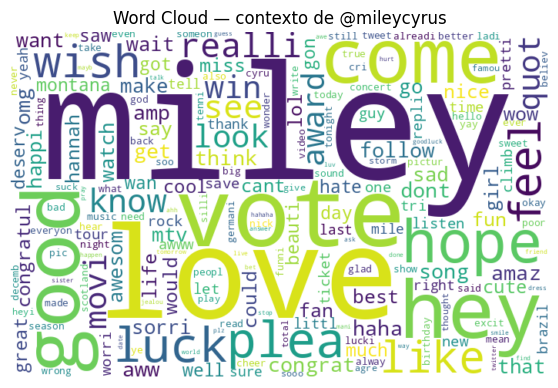


Top 10 palabras de contexto para @tommcfly:
  tom: 564
  say: 175
  hey: 154
  love: 140
  good: 137
  plea: 136
  come: 112
  like: 104
  miss: 99
  haha: 99


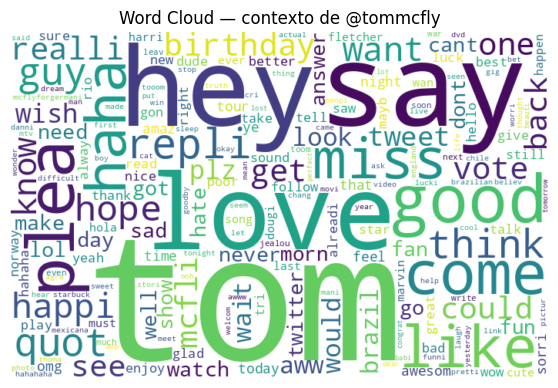


Top 10 palabras de contexto para @ddlovato:
  demi: 420
  love: 239
  wish: 163
  hey: 120
  come: 114
  hope: 108
  plea: 105
  quot: 104
  wait: 92
  awesom: 89


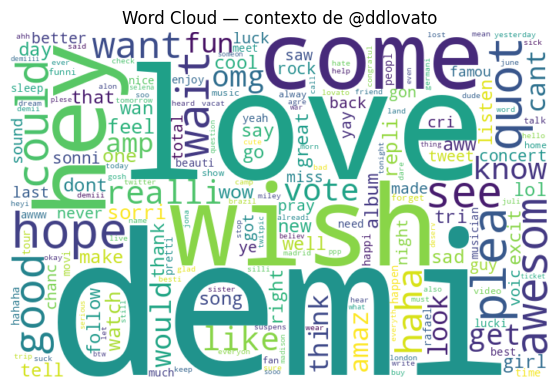

In [18]:
def top10_wordcloud_for_user(corpus_df, username):
    contexts = corpus_df["content"].apply(lambda t: get_context_words(t, username))
    full_context_text = " ".join(contexts)

    tokens = clean_and_tokenize(full_context_text)
    # Stemming + lematización, tal como pide el enunciado
    processed = [lemmatizer.lemmatize(stemmer.stem(t)) for t in tokens]

    freq = Counter(processed)
    top10 = dict(freq.most_common(10))

    print(f"\nTop 10 palabras de contexto para @{username}:")
    for word, count in top10.items():
        print(f"  {word}: {count}")

    wc = WordCloud(width=700, height=450, background_color="white")
    wc.generate_from_frequencies(freq)
    plt.figure(figsize=(7, 4.5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud — contexto de @{username}")
    plt.show()

    return top10

top10_by_user = {}
for user in top_3_users:
    top10_by_user[user] = top10_wordcloud_for_user(corpora[user], user)


### Comentario:

Los 3 usuarios más citados son **@mileycyrus** (4,580 menciones), **@tommcfly**
(3,904 menciones, Tom Fletcher de la banda McFly) y **@ddlovato** (3,474 menciones,
Demi Lovato) — los tres son celebridades/músicos activos en 2009, año del dataset.

Top-10 de palabras de contexto por usuario:

| @mileycyrus | @tommcfly | @ddlovato |
|---|---|---|
| miley, love, vote, hey, good, come, hope, plea(se), luck, wish | tom, say, hey, love, good, plea(se), come, like, miss, haha | demi, love, wish, hey, come, hope, plea(se), quot(e), wait, awesom(e) |